In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [159]:
df = pd.read_csv(
    r"C:\Users\kadit\MedicalPlan-Xray\data\processed\clean_data.csv"
)

In [160]:
df.head()

,user_id,gender,age,state_tier,occupation_class,salary_bracket,total_income_inr,is_smoker,family_members,medical_plan,annual_expenditure_inr
0,1,Male,19,Tier-2,Low-Risk,Tier-1,203736,0,5,Medium,89149
1,2,Female,20,Tier-1,Low-Risk,Tier-2,527824,0,6,Medium,115346
2,3,Male,46,Tier-2,High-Risk,Tier-1,233707,0,3,High,128494
3,4,Male,66,Tier-1,Low-Risk,Tier-1,330331,0,1,Medium,126971
4,5,Male,42,Tier-1,Low-Risk,Tier-2,879201,0,6,Medium,142701


1. Seprating features and target variables:

In [161]:
X = df.drop(columns=['medical_plan'])
y = df['medical_plan']

2. Checking target distribution:

In [162]:
y.value_counts()

medical_plan
High      418
Medium    407
Low       155
Name: count, dtype: int64

In [163]:
y.value_counts(normalize=True) * 100

medical_plan
High      42.653061
Medium    41.530612
Low       15.816327
Name: proportion, dtype: float64

3. Train test split:

In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [165]:
X_train.shape
X_test.shape
y_train.value_counts(normalize=True)*100
y_test.value_counts(normalize=True)*100

medical_plan
High      42.857143
Medium    41.326531
Low       15.816327
Name: proportion, dtype: float64

4. Seperating by column types:

In [166]:
X_train.dtypes

user_id                   int64
gender                      str
age                       int64
state_tier                  str
occupation_class            str
salary_bracket              str
total_income_inr          int64
is_smoker                 int64
family_members            int64
annual_expenditure_inr    int64
dtype: object

In [167]:
cat_cols = [
    'gender',
    'state_tier',
    'occupation_class',
    'salary_bracket'
]

num_cols = [
    'age',
    'total_income_inr',
    'is_smoker',
    'family_members',
    'annual_expenditure_inr'
]

In [168]:
print(cat_cols)
print(num_cols)

['gender', 'state_tier', 'occupation_class', 'salary_bracket']
['age', 'total_income_inr', 'is_smoker', 'family_members', 'annual_expenditure_inr']


1st production grade pipeline:

Preprocessor
->
Logistic Regression
->
Train
->
Predict
->
Evaluate

5. Preprocessing for numerical columns:

In [169]:
num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

6. Preprocessing for categorical columns:

In [170]:
cat_transformer = Pipeline(
    steps=[
        (
            'encoder',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            )
        )
    ]
)

7. Combine both:

In [171]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [172]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

8. Building Baseline model and pipeline:

In [173]:
baseline_model = Pipeline (
    steps= [('preprocessor',preprocessor),
            ('model',
            LogisticRegression(
                random_state=42,
                max_iter=1000
            ))]
)

# max_iter = 1000, Sometimes Logistic Regression doesn't converge.Sometimes Logistic Regression doesn't converge.

9. Train the model:

In [174]:
baseline_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Workflow so far: 
Fit Preprocessor
->
Transform Data
->
Train Logistic Regression
->
Store Everything

10. Make predictions:

In [175]:
y_pred = baseline_model.predict(X_test)

10.1 Accuracy:

In [176]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7806


In [177]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.84      0.92      0.88        84
         Low       0.56      0.45      0.50        31
      Medium       0.78      0.77      0.78        81

    accuracy                           0.78       196
   macro avg       0.73      0.71      0.72       196
weighted avg       0.77      0.78      0.77       196



The model struggles to identify Low medical plans.

What does this tell us for future improvements?

Potential improvements:

- Better features.
- Class imbalance techniques.
- Tree-based models.
- Hyperparameter tuning.

10.2 Confusion Matrix:

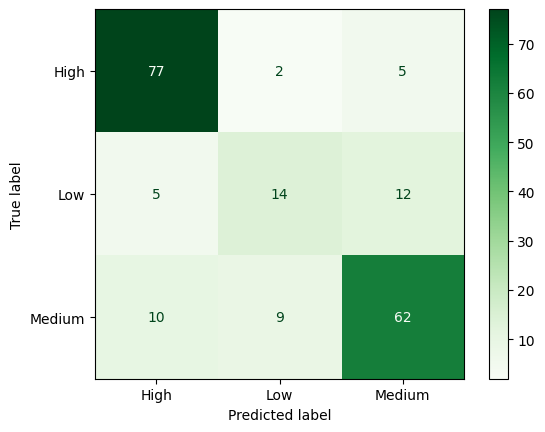

In [178]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline_model.classes_
)

disp.plot(cmap='Greens')
plt.show()

1.  Creating new features as discussed in 04_feature_engineering:

In [179]:
X = df.drop(columns=['medical_plan'])
y = df['medical_plan']

In [180]:
X['expense_ratio'] = X['annual_expenditure_inr'] / X['total_income_inr']

X['savings'] = (
    X['total_income_inr']
    - X['annual_expenditure_inr']
)

X['income_per_member'] = (
    X['total_income_inr']
    / X['family_members']
)

X['expenditure_per_member'] = (
    X['annual_expenditure_inr']
    / X['family_members']
)

In [181]:
X.columns

Index(['user_id', 'gender', 'age', 'state_tier', 'occupation_class',
       'salary_bracket', 'total_income_inr', 'is_smoker', 'family_members',
       'annual_expenditure_inr', 'expense_ratio', 'savings',
       'income_per_member', 'expenditure_per_member'],
      dtype='str')

In [182]:
#X = X.drop(columns=['user_id']) # not helpful info

In [183]:
X.shape

(980, 14)

In [184]:
num_cols = [
    'age',
    'total_income_inr',
    'is_smoker',
    'family_members',
    'annual_expenditure_inr',
    'expense_ratio',
    'savings',
    'income_per_member',
    'expenditure_per_member'
]

In [185]:
cat_cols = [
    'gender',
    'state_tier',
    'occupation_class',
    'salary_bracket'
]

In [186]:
print(len(num_cols))
print(len(cat_cols))

9
4


2. Train test split:

In [187]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [188]:
X_train.shape

(784, 14)

In [189]:
X_test.shape

(196, 14)

3. Creating a new pipeline with new features in it that we created:

3.1 Numerical Transformer:

In [190]:
fe_num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

3.2 Categorical Transformer:

In [191]:
fe_cat_transformer = Pipeline(
    steps=[
        ('encoder',
         OneHotEncoder(
             drop='first',
             handle_unknown='ignore'
         )
        )
    ]
)

3.3 Column Transformer:

In [192]:
fe_preprocessor = ColumnTransformer(
    transformers=[
        ('num', fe_num_transformer, num_cols),
        ('cat', fe_cat_transformer, cat_cols)
    ]
)

In [193]:
fe_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

4. New FE model:

In [194]:
fe_model = Pipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('model',
         LogisticRegression(
             random_state=42,
             max_iter=1000,
             class_weight='balanced'
         ))
    ]
)

4.1 Train the model:

In [195]:
fe_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

4.2 Make predicitions:

In [196]:
fe_y_pred = fe_model.predict(X_test)

In [197]:
fe_accuracy = accuracy_score(y_test, fe_y_pred)
print(f"Accuracy: {fe_accuracy:.4f}")

Accuracy: 0.7500


In [198]:
print(classification_report(y_test, fe_y_pred))

              precision    recall  f1-score   support

        High       0.84      0.89      0.87        84
         Low       0.47      0.61      0.54        31
      Medium       0.79      0.65      0.72        81

    accuracy                           0.75       196
   macro avg       0.70      0.72      0.71       196
weighted avg       0.76      0.75      0.75       196



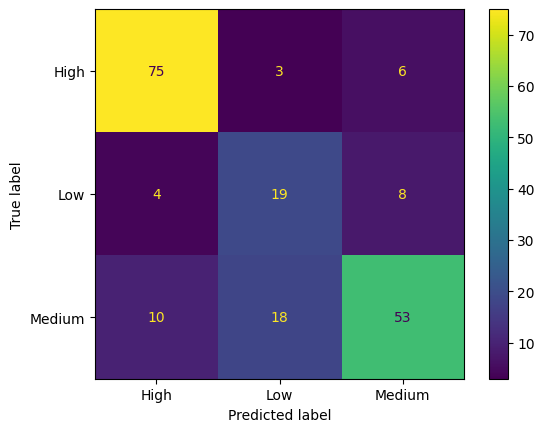

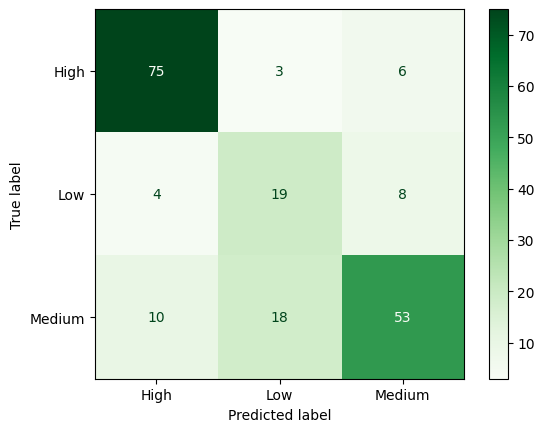

In [199]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    fe_y_pred
)

disp.plot(cmap='Greens')
plt.show()

5. Applying SMOTE for making syntheic columns in order to balance data:

In [200]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [201]:
# Creating object:

smote = SMOTE(
    random_state=42
)

5.1 Applying SMOTE on training data:

SMOTE can only be applied on numerical data.

In [202]:
'''X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)'''

'X_train_smote, y_train_smote = smote.fit_resample(\n    X_train,\n    y_train\n)'

5.2 Creating a new pipeline in order to apply SMOTE:

In [203]:
smote_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

In [204]:
smote_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

5.3 Making predicitions:

In [205]:
smote_y_pred = smote_model.predict(X_test)

In [206]:
smote_accuracy = accuracy_score(y_test, smote_y_pred)
print(f"Accuracy: {smote_accuracy:.4f}")

Accuracy: 0.7500


In [207]:
print(classification_report(y_test, smote_y_pred))

              precision    recall  f1-score   support

        High       0.84      0.87      0.85        84
         Low       0.50      0.68      0.58        31
      Medium       0.79      0.65      0.72        81

    accuracy                           0.75       196
   macro avg       0.71      0.73      0.72       196
weighted avg       0.77      0.75      0.75       196



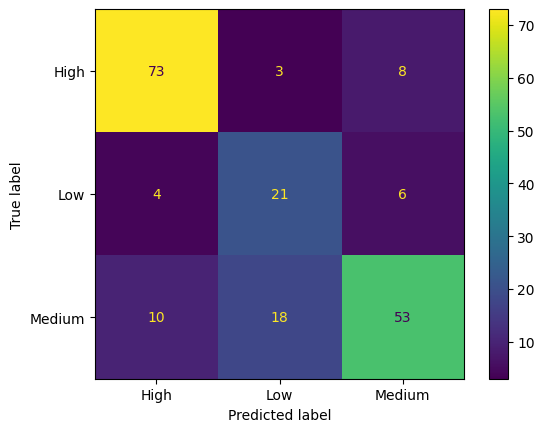

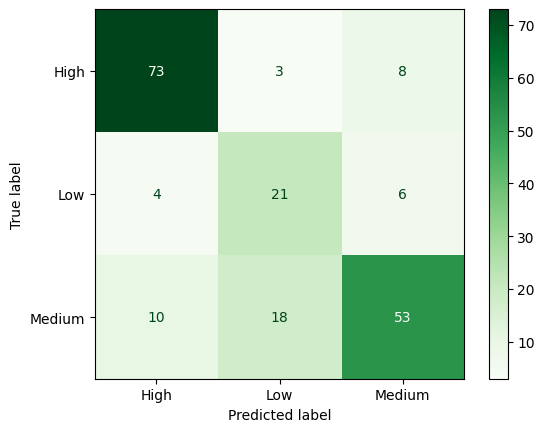

In [208]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    smote_y_pred
)

disp.plot(cmap='Greens')
plt.show()

Comparing models O/Ps:

| Model                 | Accuracy | Low Recall | Low F1   |
| --------------------- | -------- | ---------- | -------- |
| Baseline              | 78.06%   | 0.45       | 0.50     |
| Feature Engineering   | 77.55%   | 0.52       | 0.54     |
| Class Weight Balanced | 75.00%   | 0.61       | 0.54     |
| SMOTE                 | 75.00%   | **0.68**   | **0.58** |


6. Decision Tree + SMOTE:

In [209]:
from sklearn.tree import DecisionTreeClassifier

6.1 Pipeline:

In [210]:
smote_dt_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

6.2 Train:

In [211]:
smote_dt_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

6.3 Predictions:

In [212]:
smote_dt_pred = smote_dt_model.predict(X_test)

In [213]:
print(
    f"Accuracy: {
        accuracy_score(y_test, smote_dt_pred):.4f
    }"
)

Accuracy: 0.7704


In [214]:
print(
    classification_report(
        y_test,
        smote_dt_pred
    )
)

              precision    recall  f1-score   support

        High       0.80      0.82      0.81        84
         Low       0.62      0.74      0.68        31
      Medium       0.81      0.73      0.77        81

    accuracy                           0.77       196
   macro avg       0.74      0.76      0.75       196
weighted avg       0.78      0.77      0.77       196



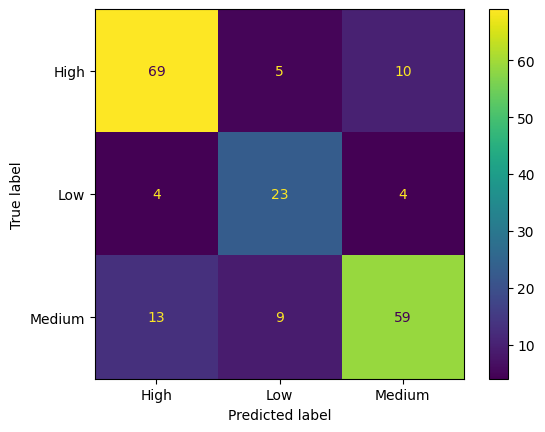

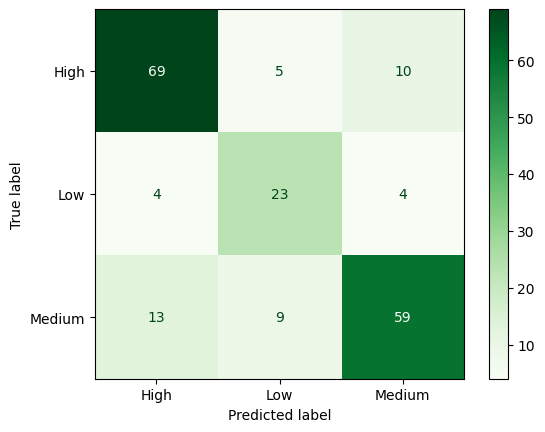

In [215]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    smote_dt_pred
)

disp.plot(cmap='Greens')
plt.show()

| Model                     | Accuracy   | Low Recall | Low F1   |
| ------------------------- | ---------- | ---------- | -------- |
| Baseline LR               | 78.06%     | 0.45       | 0.50     |
| FE + LR                   | 77.55%     | 0.52       | 0.54     |
| Balanced LR               | 75.00%     | 0.61       | 0.54     |
| SMOTE + LR                | 75.00%     | 0.68       | 0.58     |
| **SMOTE + Decision Tree** | **77.04%** | **0.74**   | **0.68** |


Now let's try Random Forest + SMOTE as DT are notorious for -> high variance and overfitting, therefore we use RF because:

- Random Forest reduces overfitting.
- Handles nonlinear relationships.
- Works extremely well on tabular data.
- Usually performs better than a single Decision Tree.

7. Random Forest + SMOTE:

In [216]:
from sklearn.ensemble import RandomForestClassifier

In [217]:
smote_rf_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model',
         RandomForestClassifier(
             n_estimators=100,
             random_state=42
         ))
    ]
)

In [218]:
smote_rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [219]:
smote_rf_pred = smote_rf_model.predict(X_test)

In [220]:
print(
    f"Accuracy: {
        accuracy_score(y_test, smote_rf_pred):.4f
    }"
)

Accuracy: 0.8010


In [221]:
print(
    classification_report(
        y_test,
        smote_rf_pred
    )
)

              precision    recall  f1-score   support

        High       0.80      0.88      0.84        84
         Low       0.69      0.71      0.70        31
      Medium       0.85      0.75      0.80        81

    accuracy                           0.80       196
   macro avg       0.78      0.78      0.78       196
weighted avg       0.80      0.80      0.80       196



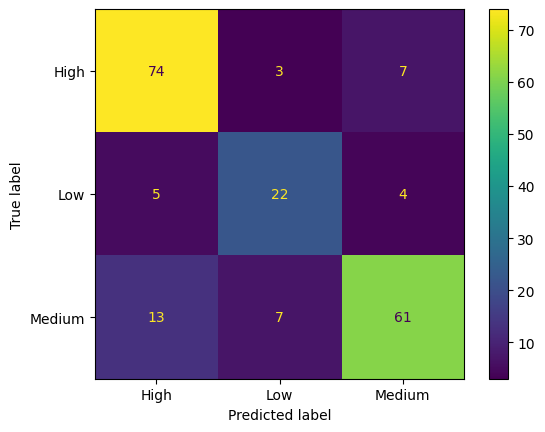

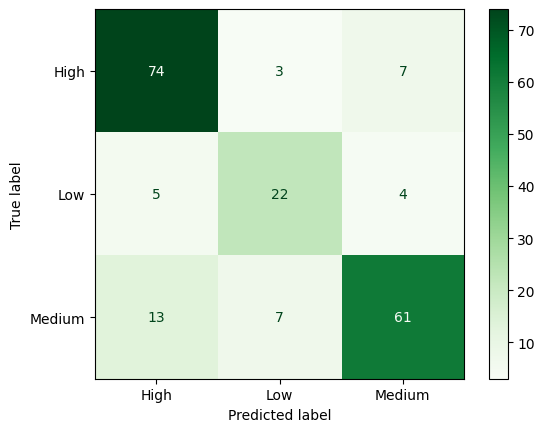

In [222]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    smote_rf_pred
)

disp.plot(cmap='Greens')
plt.show()

So far the most balanced model is SMOTE + RF:

| Model        | Accuracy   | Low Recall | Low F1   |
| ------------ | ---------- | ---------- | -------- |
| Baseline LR  | 78.06%     | 0.45       | 0.50     |
| Balanced LR  | 75.00%     | 0.61       | 0.54     |
| SMOTE + LR   | 75.00%     | 0.68       | 0.58     |
| SMOTE + DT   | 77.04%     | 0.74       | 0.68     |
| SMOTE + RF | **80.10%** | **0.71**   | **0.70** |


8. XGBoost + SMOTE:

In [223]:
from xgboost import XGBClassifier

In [224]:
smote_xgb_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            random_state=42,
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            objective='multi:softmax',
            num_class=3,
            eval_metric='mlogloss'
        ))
    ]
)

In [225]:
y.unique() #XGBoost will throw an error because it expects multiclass labels as integers (0, 1, 2).

<ArrowStringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

8.1 Applying Label encoding:

In [226]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

8.2 Checkng mapping:

In [227]:
dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

8.3 Train test split:

In [228]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

8.4 Creating the pipeline:

In [229]:
smote_xgb_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            random_state=42,
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss'
        ))
    ]
)

In [230]:
smote_xgb_model.fit(X_train_xgb, y_train_xgb)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [231]:
smote_xgb_pred = smote_xgb_model.predict(X_test_xgb)

In [232]:
xgb_accuracy = accuracy_score(y_test_xgb, smote_xgb_pred)
print(f"Accuracy: {xgb_accuracy:.4f}")

Accuracy: 0.8112


In [233]:
print(
    classification_report(
        y_test_xgb,
        smote_xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.89      0.85        84
           1       0.71      0.71      0.71        31
           2       0.86      0.77      0.81        81

    accuracy                           0.81       196
   macro avg       0.79      0.79      0.79       196
weighted avg       0.81      0.81      0.81       196



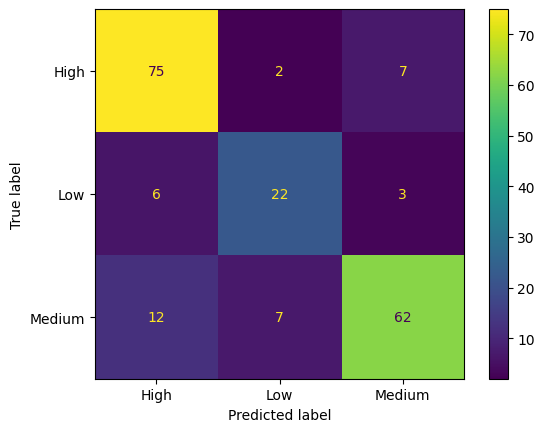

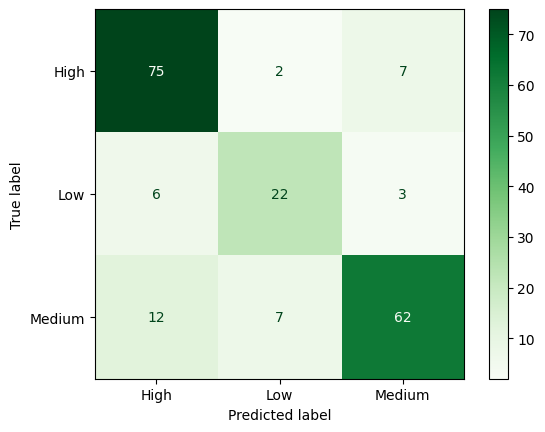

In [234]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    smote_xgb_pred,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Greens')
plt.show()

Comparing with RF:

| Metric      | RF + SMOTE | XGB + SMOTE  |
| ----------- | ---------- | ------------ |
| Accuracy    | 80.10%     | 81.12%       |
| Low Recall  | 0.71       | 0.71         |
| Low F1      | 0.70       | 0.71         |
| Macro F1    | 0.78       | 0.79         |
| Weighted F1 | 0.80       | 0.81         |


Conclusion:

XGB model:

- Predicts the majority class well.

- Maintains good detection of minority plans.

- Has the highest overall performance.

- Gives balanced predictions across all three classes.

In [236]:
import joblib

joblib.dump(smote_xgb_model, '../models/smote_xgb_model.pkl')
joblib.dump(X_train_xgb, '../models/X_train_xgb.pkl')
joblib.dump(X_test_xgb, '../models/X_test_xgb.pkl')
joblib.dump(y_train_xgb, '../models/y_train_xgb.pkl')
joblib.dump(y_test_xgb, '../models/y_test_xgb.pkl')

['../models/y_test_xgb.pkl']